## Reproducing the Wine Results

In [1]:
#Code Block 1
## import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
#Code Block 2
## load the data

df_red = pd.read_csv('../../DATA/wine+quality/winequality-red.csv', sep=';')
display(df_red.info())
df_red.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Check the Datset Stats

In [3]:
#Code Block 3
## check summary statistics of the data
medians = df_red.median()
stats_table = pd.concat([df_red.describe().T[['mean', 'std', 'min', 'max']], medians], axis = 1)
stats_table = stats_table.rename(columns = {0: 'median'})
stats_table = stats_table.round(2)
## save the stats table
stats_table.to_csv('../../Data/wine_quality_stats.csv', index = True)
stats_table

,mean,std,min,max,median
fixed acidity,8.32,1.74,4.60,15.90,7.90
volatile acidity,0.53,0.18,0.12,1.58,0.52
citric acid,0.27,0.19,0.00,1.00,0.26
residual sugar,2.54,1.41,0.90,15.50,2.20
chlorides,0.09,0.05,0.01,0.61,0.08
free sulfur dioxide,15.87,10.46,1.00,72.00,14.00
total sulfur dioxide,46.47,32.90,6.00,289.00,38.00
density,1.00,0.00,0.99,1.00,1.00
pH,3.31,0.15,2.74,4.01,3.31
sulphates,0.66,0.17,0.33,2.00,0.62


### Data Preprocessing

* label encoding: good, normal, bad
    * bad wine - quality < 5
    * normal wine - quality 5-6
    * good wine - quality 7-10
* exclude duplicate entries
* exclude data points with missing values


#### Label Encoding

In [4]:
#Code Block 4
## encode the quality feature

def quality_code(df):
    if df['quality'] < 5:
        return 'bad'
    elif df['quality'] == 5 or df['quality'] == 6:
        return 'normal'
    else:
        return 'good'

df_red['quality_label'] = df_red.apply(quality_code, axis = 1)
df_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,normal
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,normal
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,normal
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,normal
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,normal


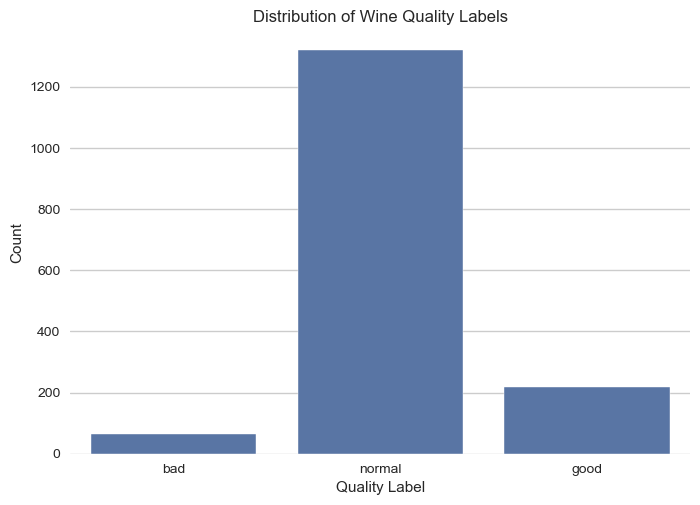

quality_label
normal    82.49
good      13.57
bad        3.94
Name: proportion, dtype: float64


In [5]:
#Code Block 5
## check the distribution of the quality labels
sns.countplot(x = 'quality_label', data = df_red, order = ['bad', 'normal', 'good'])
plt.title('Distribution of Wine Quality Labels')
plt.xlabel('Quality Label')
plt.ylabel('Count')
plt.savefig('../../Analysis/Figures/wine_quality_distribution.png', dpi = 300, bbox_inches = 'tight')
plt.show()

## display percentage of each quality label
quality_counts = df_red['quality_label'].value_counts(normalize = True) * 100
print(quality_counts.round(2))

#### Exclude any Duplicate Entries

In [6]:
#Code Block 6
## exclude any duplicate rows

initial_shape = df_red.shape
df_red = df_red.drop_duplicates()
final_shape = df_red.shape
print(f'Initial shape: {initial_shape}')
print(f'Final shape after dropping duplicates: {final_shape}')

Initial shape: (1599, 13)
Final shape after dropping duplicates: (1359, 13)


In [8]:
#Code Block 7
## recheck the stats table after dropping duplicates
### drop quality labels to add back in later
qualities = df_red['quality_label']
df_red = df_red.drop(columns = ['quality_label'])
medians = df_red.median()
stats_table = pd.concat([df_red.describe().T[['mean', 'std', 'min', 'max']], medians], axis = 1)
stats_table = stats_table.rename(columns = {0: 'median'})
stats_table = stats_table.round(2)

### readd quality labels to the data frame
df_red['quality_label'] = qualities
stats_table.to_csv('../../Data/wine_quality_stats.csv', index = True)
stats_table

,mean,std,min,max,median
fixed acidity,8.31,1.74,4.60,15.90,7.90
volatile acidity,0.53,0.18,0.12,1.58,0.52
citric acid,0.27,0.20,0.00,1.00,0.26
residual sugar,2.52,1.35,0.90,15.50,2.20
chlorides,0.09,0.05,0.01,0.61,0.08
free sulfur dioxide,15.89,10.45,1.00,72.00,14.00
total sulfur dioxide,46.83,33.41,6.00,289.00,38.00
density,1.00,0.00,0.99,1.00,1.00
pH,3.31,0.16,2.74,4.01,3.31
sulphates,0.66,0.17,0.33,2.00,0.62


In [9]:
#Code Block 8
## exclude data with missing values

### check for missing values
missing_values = df_red.isnull().sum()
print(missing_values)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_label           0
dtype: int64


## Data Analysis

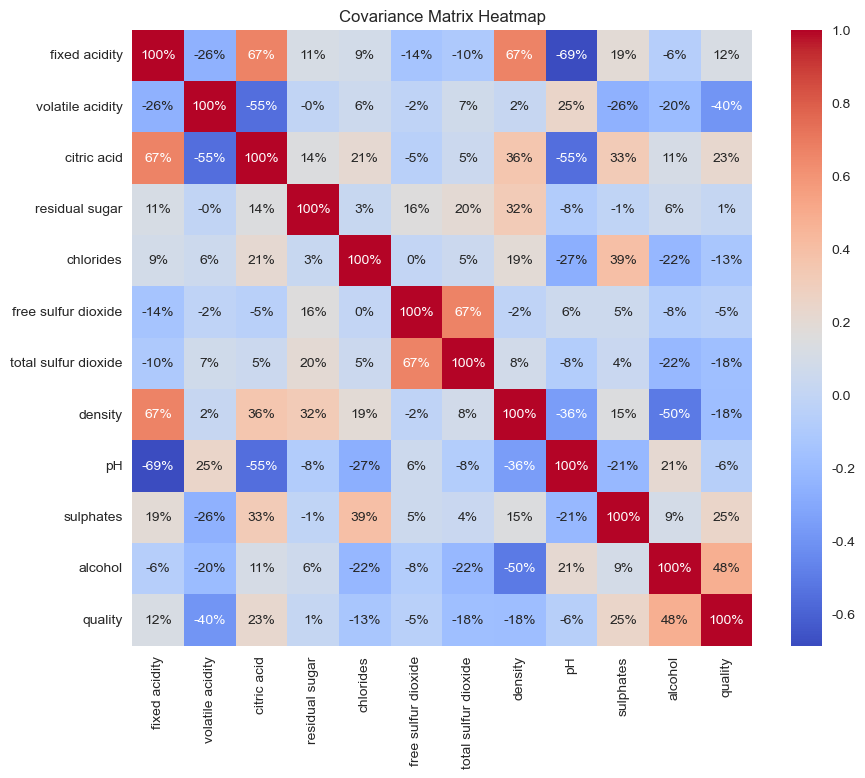

In [10]:
#Code Block 9
## create a covariance matrix for the features
corr_matrix = df_red.drop(columns = ['quality_label']).corr()

## create a heatmap with pearson correlation coefficients of covariance
plt.figure(figsize = (10, 8))
### convert correlation matrix to percents
def percent_formatter(x, _):
    return f'{x * 100:.0f}%'

### heatmap with formatting as percentages and no decimal places
sns.heatmap(
    corr_matrix, 
    annot=True,
    fmt='',
    cmap='coolwarm', 
    cbar_kws={'format': '%.1f'},  # Keep color bar in decimal format
    xticklabels=corr_matrix.columns,
    yticklabels=corr_matrix.columns
)

for text in plt.gca().texts:
    text.set_text(percent_formatter(float(text.get_text()), None))

plt.title('Covariance Matrix Heatmap')
plt.savefig('../../Analysis/Figures/covariance_heatmap.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [11]:
#Code Block 10
## correlation table with top 10 ranked by abolute value of correlation with quality
#########################
### rank Name Correlation (with quality)
###  1  alcohol 48%

# Calculate correlations with quality
correlations_with_quality = corr_matrix['quality'].sort_values(key=abs, ascending=False)

# Create a correlation table
correlation_table = pd.DataFrame({
    'Rank': range(0, len(correlations_with_quality)),
    'Feature': correlations_with_quality.index,
    'Correlation': correlations_with_quality.values.round(2)
})
correlation_table['Correlation'] = correlation_table['Correlation'].apply(lambda x: f'{x * 100:.0f}%')

# Exclude the 'quality' feature itself
correlation_table = correlation_table[correlation_table['Feature'] != 'quality']

# Keep the top 10 features
correlation_table = correlation_table.head(10)

# Reset the index
correlation_table = correlation_table.reset_index(drop=True)
correlation_table.to_csv('../../Data/wine_quality_correlations.csv', index = False)
print("Correlation with Quality:")
correlation_table


Correlation with Quality:


,Rank,Feature,Correlation
0,1,alcohol,48%
1,2,volatile acidity,-40%
2,3,sulphates,25%
3,4,citric acid,23%
4,5,density,-18%
5,6,total sulfur dioxide,-18%
6,7,chlorides,-13%
7,8,fixed acidity,12%
8,9,pH,-6%
9,10,free sulfur dioxide,-5%


### Residual Sugar vs. Quality

/var/folders/mm/xkwn8c6n2djgfy47v6p2myf00000gn/T/ipykernel_31869/2265644629.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


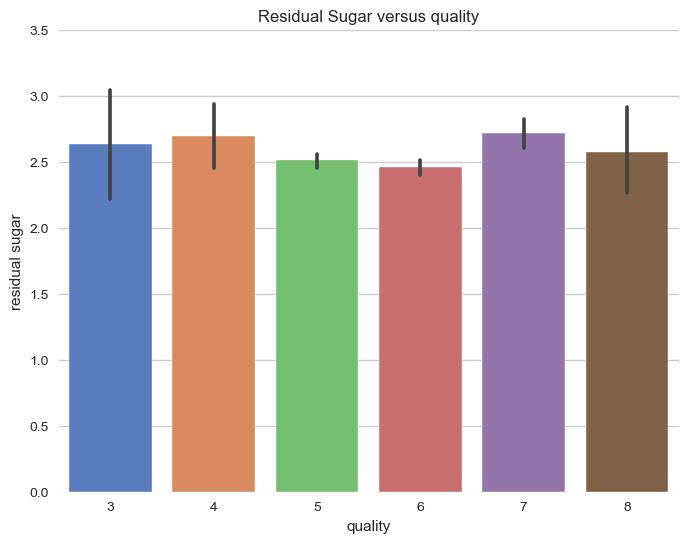

In [12]:
#Code Block 11
## create a colored bar chart with error bars for residual sugar by quality level

plt.figure(figsize = (8, 6))
sns.barplot(
    x='quality', 
    y='residual sugar', 
    data=df_red,
    errorbar = ('ci', 68),
    palette='muted'
)
plt.title('Residual Sugar versus quality')
plt.ylim(0, 3.5)
plt.savefig('../../Analysis/Figures/residual_sugar_by_quality.png', dpi = 300, bbox_inches = 'tight')
plt.show()

/var/folders/mm/xkwn8c6n2djgfy47v6p2myf00000gn/T/ipykernel_31869/2689710451.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


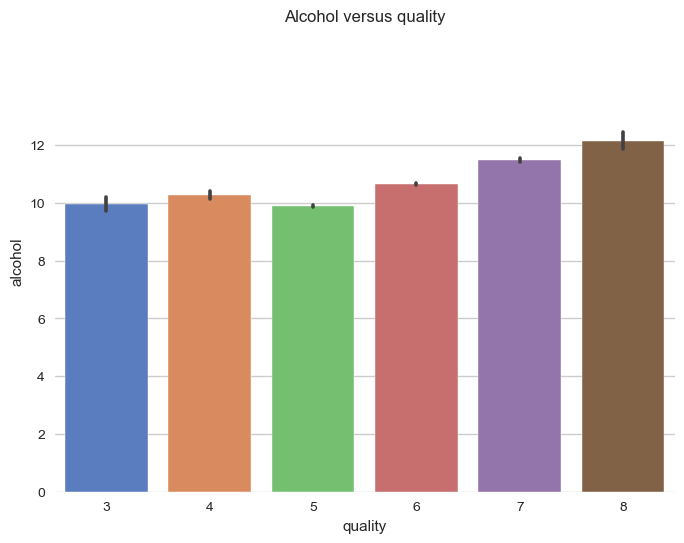

In [13]:
#Code Block 12
## colored bar chart with error bars for alcohol by quality level

plt.figure(figsize = (8, 6))
sns.barplot(
    x='quality',
    y='alcohol',
    data=df_red,
    errorbar = ('ci', 68),
    palette='muted'
)
plt.title('Alcohol versus quality')
plt.ylim(0,16)
plt.yticks(np.arange(0, 14, 2))
plt.savefig('../../Analysis/Figures/alcohol_by_quality.png', dpi = 300, bbox_inches = 'tight')
plt.show()

## Classification

### Support Vector Machines

In [14]:
#Code Block 13
## import necessary libraries for machine learning model
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

In [15]:
#Code Block 14
## prepare data for analysis

#df_red.columns

X = df_red.drop(columns = ['residual sugar', 'quality', 'quality_label'], axis = 1)
y = df_red['quality_label']

print(X.shape)
y.shape

(1359, 10)


(1359,)

In [16]:
#Code Block 15
## standardize the data and split into training and testing sets
from sklearn.discriminant_analysis import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state = 42, stratify = y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1087, 10)
X_test shape: (272, 10)
y_train shape: (1087,)
y_test shape: (272,)


In [17]:
#Code Block 16
## train the SVC

svc_model = SVC(kernel = 'rbf', random_state = 42, probability= True)
## fit the model
svc_model.fit(X_train, y_train)

## make predictions on the target
y_pred = svc_model.predict(X_test)

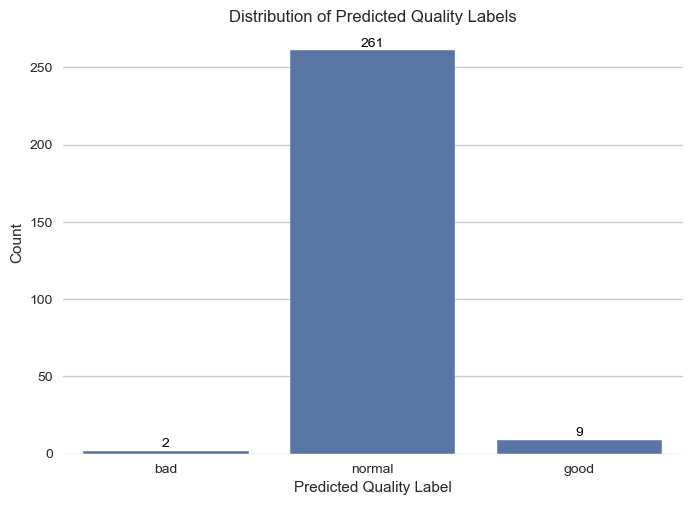

Percentage of each predicted quality label:
Bad: 0.74%
Normal: 95.96%
Good: 3.31%


In [18]:
#Code Block 17
## examine the predictions (distribution with labels)
ax = sns.countplot(x=y_pred, order=['bad', 'normal', 'good'])
plt.title('Distribution of Predicted Quality Labels')
plt.xlabel('Predicted Quality Label')
plt.ylabel('Count')

# Add labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.show()
print("Percentage of each predicted quality label:")
print(f"Bad: {np.mean(y_pred == 'bad') * 100:.2f}%")
print(f"Normal: {np.mean(y_pred == 'normal') * 100:.2f}%")
print(f"Good: {np.mean(y_pred == 'good') * 100:.2f}%")


In [19]:
#Code Block 18
## function for evaluating the model performance
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import label_binarize

def modeltraintest(vartrain, vartest, y_train, y_test, y_pred, model):    
    model_pred = y_pred
    model_prob = model.predict_proba(vartest)

    # 1) Assess the accuracy with the test data
    score = model.score(vartest, y_test)
    print('XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXXXX')
    print(round(score, 6))
    print("")

    # 2) Confusion Matrix
    print('XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX')
    print(confusion_matrix(y_test, model_pred))
    print("")

    # 3) Classification Report
    print('XXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXX')
    print(classification_report(y_test, model_pred))
    print('')

    # 4) ROC AUC Score and Chart
    print('XXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXXXX')
    print('')
    
    # Binarize the labels for multi-class ROC AUC
    y_test_binarized = label_binarize(y_test, classes=['bad', 'normal', 'good'])
    n_classes = y_test_binarized.shape[1]
    
    # Compute ROC curve and ROC AUC for each class
    fpr = {}
    tpr = {}
    roc_auc = {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], model_prob[:, i])
        roc_auc[i] = roc_auc_score(y_test_binarized[:, i], model_prob[:, i])
    
    # Plot ROC curve for each class
    plt.figure()
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

    # Print overall ROC AUC score
    overall_roc_auc = roc_auc_score(y_test_binarized, model_prob, multi_class='ovr')
    print(f'Overall ROC AUC Score: {overall_roc_auc:.4f}')
    print('')

    # 5) Cross-validation scores
    print('XXXXXXXXXXXXXX CROSS VALIDATION XXXXXXXXXXXXXXXXXX')
    print('')
    cv_scores = cross_val_score(model, vartrain, y_train, cv=5, scoring='accuracy')
    print('CV Accuracy Scores:')
    print(cv_scores)
    print('')
    cv_rocauc = cross_val_score(model, vartrain, y_train, cv=5, scoring='roc_auc_ovr')
    print('CV ROC AUC:')
    print(cv_rocauc)
    print('')
    print('XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX')

XXXXXXXXXXXXXXXX ACCURACY SCORE XXXXXXXXXXXXXXXXXX
0.827206

XXXXXXXXXXXXXXXX CONFUSION MATRIX XXXXXXXXXXXXXXXX
[[  0   0  13]
 [  0   7  30]
 [  2   2 218]]

XXXXXXXXXXXXXX CLASSIFICATION REPORT XXXXXXXXXXXXXX
              precision    recall  f1-score   support

         bad       0.00      0.00      0.00        13
        good       0.78      0.19      0.30        37
      normal       0.84      0.98      0.90       222

    accuracy                           0.83       272
   macro avg       0.54      0.39      0.40       272
weighted avg       0.79      0.83      0.78       272


XXXXXXXXXXXXXX ROC AUC SCORE AND CHART XXXXXXXXXXXXXXXXXX



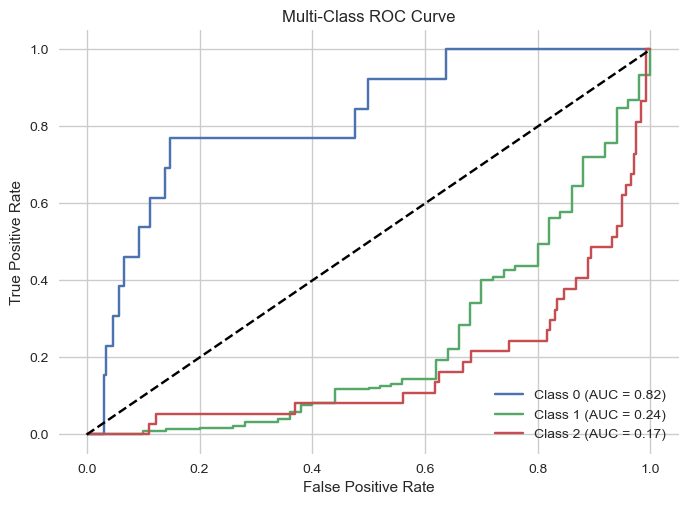

Overall ROC AUC Score: 0.4101

XXXXXXXXXXXXXX CROSS VALIDATION XXXXXXXXXXXXXXXXXX

CV Accuracy Scores:
[0.82110092 0.82568807 0.84792627 0.84331797 0.8202765 ]

CV ROC AUC:
[0.78423523 0.75559187 0.74308439 0.78523702 0.73805736]

XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX


In [20]:
# Code Block 19
## evaluate the model performance with the function

modeltraintest(X_train, X_test, y_train, y_test, y_pred, svc_model)